# **Test d'intégration du loader/Module/InfoNCELoss pour la phase patient-wise-learning**

In [1]:
%load_ext autoreload
%autoreload 2
from gbmhackathon.training.patientwise import *
from gbmhackathon.models.mme import MultiModalEncoder
from gbmhackathon.utils.loss_functions import InfoNCELoss, RegularizedInfoNCELoss, SmoothingFunction
from gbmhackathon.s3_loader import load_s3

import os
from copy import deepcopy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# To investigate gradients
from torchviz import make_dot

import torch
from torch.utils.data import DataLoader
from torch.optim import Adam

In [2]:
name_emb_dict = {"hne":"embeddings_HnE_OptimusH0.pkl",
"spatial":"2025-03-23_18-32_spatial_emb_V1.pkl",
"clinical":"2025-03-30_14-23_clinical_emb_V1.pkl",
"wes":"2025-04-05_13-40_wes_emb_V1.pkl"}
pkl_storage_folder = "embedding_V1"

In [3]:
dataset = PatientLearningDataset(name_emb_dict, pkl_storage_folder)
BATCH_SIZE = 32
dataloader = DataLoader(dataset, BATCH_SIZE, shuffle=True, collate_fn=collate_patient_wise)

In [4]:
batch_all = [dataset.__getitem__(idx) for idx in dataset.ind2patient]
batch_all = collate_patient_wise(batch_all)

## Pour la loss, il nous faut un dictionnaire qui associe chaque patient à un ID
On fait bien attention à indiquer les rechutes comme le même patient

In [5]:
missing_mods = load_s3("s3://abstra-project-storage-lttemftb/1b75dc89-ad27-4a65-9e7f-877d1b4f36fc/missing_mod_per_samples.pkl")

In [6]:
all_ids = list(missing_mods.keys())
patient_map = {key: i for key, i in zip(all_ids, [k for k in range(1,len(all_ids)+1)])}
for patient_id, idx in patient_map.items():
    if patient_id.endswith('b'): # pour les rechutes on met le même index que le sample original
        patient_map[patient_id] = idx - 1
patient_map

{'HK_G_001a': 1,
 'HK_G_002a': 2,
 'HK_G_003a': 3,
 'HK_G_004a': 4,
 'HK_G_005a': 5,
 'HK_G_006a': 6,
 'HK_G_007a': 7,
 'HK_G_008a': 8,
 'HK_G_009a': 9,
 'HK_G_010a': 10,
 'HK_G_011a': 11,
 'HK_G_012a': 12,
 'HK_G_013a': 13,
 'HK_G_014a': 14,
 'HK_G_015a': 15,
 'HK_G_016a': 16,
 'HK_G_017b': 16,
 'HK_G_018a': 18,
 'HK_G_019a': 19,
 'HK_G_020a': 20,
 'HK_G_021a': 21,
 'HK_G_022a': 22,
 'HK_G_023a': 23,
 'HK_G_024a': 24,
 'HK_G_025a': 25,
 'HK_G_026a': 26,
 'HK_G_027a': 27,
 'HK_G_028a': 28,
 'HK_G_029b': 28,
 'HK_G_030a': 30,
 'HK_G_031a': 31,
 'HK_G_032a': 32,
 'HK_G_033a': 33,
 'HK_G_034a': 34,
 'HK_G_035a': 35,
 'HK_G_036b': 35,
 'HK_G_037a': 37,
 'HK_G_038a': 38,
 'HK_G_039a': 39,
 'HK_G_040a': 40,
 'HK_G_041a': 41,
 'HK_G_042a': 42,
 'HK_G_043a': 43,
 'HK_G_044b': 43,
 'HK_G_045a': 45,
 'HK_G_046a': 46,
 'HK_G_047a': 47,
 'HK_G_048a': 48,
 'HK_G_049a': 49,
 'HK_G_050a': 50,
 'HK_G_051a': 51,
 'HK_G_052a': 52,
 'HK_G_053a': 53,
 'HK_G_054a': 54,
 'HK_G_055a': 55,
 'HK_G_056a': 56,
 

In [7]:
len(patient_map)

114

## Voir à quoi ressemble l'output du loader

In [8]:
toy_batch = next(iter(dataloader))
toy_batch

(['HK_G_084b',
  'HK_G_063a',
  'HK_G_019a',
  'HK_G_087a',
  'HK_G_046a',
  'HK_G_010a',
  'HK_G_103a',
  'HK_G_032a',
  'HK_G_045a',
  'HK_G_090b',
  'HK_G_044b',
  'HK_G_039a',
  'HK_G_105b',
  'HK_G_114a',
  'HK_G_104a',
  'HK_G_031a',
  'HK_G_047a',
  'HK_G_029b',
  'HK_G_023a',
  'HK_G_038a',
  'HK_G_016a',
  'HK_G_112a',
  'HK_G_011a',
  'HK_G_088a',
  'HK_G_005a',
  'HK_G_061b',
  'HK_G_113b',
  'HK_G_034a',
  'HK_G_020a',
  'HK_G_111b',
  'HK_G_083a',
  'HK_G_036b'],
 ['hne', 'spatial', 'clinical', 'wes'],
 {'hne': tensor([[-1.1096,  0.4708,  0.2581,  ...,  0.6958,  0.6868, -0.2940],
          [ 0.0039,  0.2581,  0.3295,  ...,  0.5107,  1.0628,  0.2412],
          [ 0.4471, -0.2315,  0.3399,  ..., -0.2290,  0.3940,  0.1711],
          ...,
          [-0.5598, -0.0779, -0.4351,  ...,  0.0103,  0.7449,  0.2122],
          [-0.0760,  0.3735,  0.0821,  ...,  0.2188,  0.8244, -0.1471],
          [-0.4825, -0.5925, -0.3486,  ..., -0.1289,  0.7247,  0.1691]]),
  'spatial': tensor([[-

In [9]:
raw_emb = toy_batch[2]
inpute_size_dict = {}
for mod in raw_emb.keys():
    print(mod, raw_emb[mod].size())
    inpute_size_dict[mod] = raw_emb[mod].size(1)

hne torch.Size([32, 1536])
spatial torch.Size([32, 64])
clinical torch.Size([32, 12])
wes torch.Size([32, 1790])


# Pour instantier le MultiModalEncoder
Il faut des config pour chaque modalité, par simplicité on va définir une coquille de base et simplement ajouter la bonne dimension en entrée

In [10]:
base_config = {"layers": [1024,512,64],
        "dropout": 0.65,
        "act_fn":SmoothingFunction,
        "norm_layer":None}

high_capacity_cfg = {"layers": [1024,512,256,64],
        "dropout": 0.65,
        "act_fn":SmoothingFunction,
        "norm_layer":None}

mid_capacity_cfg = {"layers": [256,128,64,64],
        "dropout": 0.55,
        "act_fn":SmoothingFunction,
        "norm_layer":None}

small_capacity_cfg = {"layers": [128,64,64],
        "dropout": 0.45,
        "act_fn":SmoothingFunction,
        "norm_layer":None}

def adapt_base_config(base_cfg, input_size):
    base_copy = deepcopy(base_cfg)
    base_copy["layers"] = [input_size] + base_copy["layers"]
    return base_copy

hne_cfg = adapt_base_config(high_capacity_cfg, inpute_size_dict["hne"])
spatial_cfg = adapt_base_config(mid_capacity_cfg, inpute_size_dict["spatial"])
clinical_cfg = adapt_base_config(small_capacity_cfg, inpute_size_dict["clinical"])
wes_cfg = adapt_base_config(high_capacity_cfg, inpute_size_dict["wes"])

In [11]:
mme_cfg = {"hne_cfg":hne_cfg, "clinical_cfg":clinical_cfg, "wes_cfg":wes_cfg, "spatial_cfg":spatial_cfg}

In [12]:
def check_inf(tensor):
    return torch.isinf(tensor).sum() != 0
    
def check_nan(tensor):
    return torch.isnan(tensor).sum() != 0

def check(tensor):
    return check_inf(tensor) or check_nan(tensor)

def show_tensor(tensor, mode='grad'):
    plt.figure(figsize=(15,15))
    if mode == 'grad':
        if len(tensor.numpy().shape) == 1:
            plt.imshow(tensor.numpy().reshape(1,-1))
        else:
            plt.imshow(tensor.numpy())
        title = f"Average layer grad: {tensor.mean()}"
    else:
        if len(tensor.detach().numpy().shape) == 1:
            plt.imshow(tensor.detach().numpy().reshape(1,-1))
        else:
            plt.imshow(tensor.detach().numpy())
        title = f"Average layer output: {tensor.mean()}\nRatio of 0 : {(tensor == 0).sum() / tensor.size(0)}"
    plt.colorbar()
    plt.tight_layout()
    plt.title(title)
    plt.show()
    
def run_debug(EPOCHS, temp, sim, alpha=0.1, bound=-10, beta=0.2, nce_eps=1e-8, reg_eps=1e-8):
    EPOCHFLAG = 0
    problematic_batch_patient_ids = []
    # 1. Define model encoders + loss
    device = "cuda" if torch.cuda.is_available() else "cpu"
    mme = torch.jit.script(MultiModalEncoder(**mme_cfg))
    mme.to(device)
    loss_fn = RegularizedInfoNCELoss(list(name_emb_dict.keys()),
                                     patient_map, 
                                     temperature=temp, 
                                     similarity=sim, 
                                     use_all_positives=False,
                                     alpha=alpha,
                                     bound=bound,
                                     beta=beta,
                                     nce_eps=nce_eps,
                                     reg_eps=reg_eps)
    optimizer = Adam(
        mme.parameters(),
        lr=1e-3,
    )
    # print(dict(mme.named_parameters()))
    # 2. Training loop
    EPOCH_LOSSES = []
    for epoch in range(EPOCHS):
        epoch_loss = []
        for i, batch in enumerate(dataloader):
            # batch = (X_dict, patient_ids, available_modalities)
            patient_ids, modalities, X_dict, avail_mods = batch
            # print("patient_ids:", patient_ids)
            # print("modalities:", modalities)
            # print("X_dict:", X_dict)
            # print("avail_mods:", avail_mods)
        
            # print(X_dict)
            encoded = mme(X_dict)
            NANFLAG = {}
            for mod in X_dict.keys():
                if check(X_dict[mod]):
                    # print("INPUT", X_dict[mod])
                    NANFLAG[mod] = 1
                    
                for key, tensor in dict(mme.wes_net.named_parameters()).items():
                    if check(tensor):
                        # print("WEIGHTS", dict(mme.wes_net.named_parameters()))
                        NANFLAG[mod] = 1
                        break
                if check(encoded[mod]):
                    # print("ENCODED", encoded[mod])
                    NANFLAG[mod] = 1
            if 1 in list(NANFLAG.values()):
                # print("Batch patient ids:", patient_ids)
                problematic_batch_patient_ids.append(patient_ids)
                EPOCHFLAG = 1
                break
                # raise ValueError(f"Found NANs in modality {[key for key in NANFLAG.keys() if NANFLAG[key] == 1]}")
            else:
                # # 2b. Pack into expected batch for loss
                loss_batch = (encoded, patient_ids, avail_mods)
                
                # # 2c. Compute loss & backward
                loss = loss_fn(loss_batch)
                optimizer.zero_grad()
                # dot = make_dot(loss, params=dict(mme.named_parameters()), show_attrs=True, show_saved=True)
                # try:
                #     dot.view()
                # except:
                #     pass
                loss.backward()
                # for mod in X_dict.keys():
                #     param_dict = dict(mme.modality_net_map[mod].named_parameters())
                #     tensor = param_dict[list(param_dict.keys())[0]] # 1st layer parameters
                #     print(f"{key} GRADS:", tensor.grad)
                #     show_tensor(tensor.grad)
                #     print(f"Average 1st layer grad for {mod.upper()}: {tensor.mean()}")
                optimizer.step()
                epoch_loss.append(loss.item())
                # print(f"Batch {i} loss: {loss.item():.4f}")
        print(f"Epoch {epoch} loss: {np.mean(epoch_loss):.4f}".upper())
        if EPOCHFLAG == 1:
            print("BREAK")
            break
        EPOCH_LOSSES.append(np.mean(epoch_loss))
    return EPOCH_LOSSES, mme

In [13]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP

from typing import Dict, List, Optional, Union, Tuple
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches


def visualize_embeddings(embeddings: Union[torch.Tensor, np.ndarray], 
                         method: str = 'pca',
                         labels: Optional[List] = None,
                         modality_info: Optional[Dict[str, int]] = None,
                         patient_info: Optional[Dict[str, int]] = None,
                         figsize: Tuple[int, int] = (12, 10),
                         title: Optional[str] = None,
                         show_legend: bool = True,
                         colors: Optional[List[str]] = None,
                         markers: Optional[List[str]] = None,
                         save_path: Optional[str] = None) -> None:
    """
    Visualize embeddings using dimensionality reduction techniques (PCA, t-SNE, or UMAP).
    
    Parameters:
    -----------
    embeddings : torch.Tensor or numpy.ndarray
        The embeddings to visualize. Shape should be [n_samples, n_features].
    method : str, default='pca'
        The dimensionality reduction method to use ('pca', 'tsne', or 'umap').
    labels : list, optional
        Labels for each embedding point. If None, no color-coding.
    modality_info : dict, optional
        Dictionary mapping modality names to indices for color-coding by modality.
    patient_info : dict, optional
        Dictionary mapping patient IDs to indices for grouping by patient.
    figsize : tuple, default=(12, 10)
        Figure size as (width, height) in inches.
    title : str, optional
        Title for the plot. If None, a default title based on the method is used.
    show_legend : bool, default=True
        Whether to show the legend.
    colors : list, optional
        List of colors to use for different categories. If None, defaults are used.
    markers : list, optional
        List of markers to use. If None, defaults are used.
    save_path : str, optional
        Path to save the figure. If None, the figure is displayed but not saved.
    
    Returns:
    --------
    None
        The function displays or saves the visualization.
    """
    # Convert torch tensor to numpy if needed
    if isinstance(embeddings, torch.Tensor):
        embeddings = embeddings.detach().cpu().numpy()
    
    # Input validation
    if embeddings.ndim != 2:
        raise ValueError(f"Expected 2D input, got shape {embeddings.shape}")
    
    n_samples, n_features = embeddings.shape
    
    # Choose dimensionality reduction method
    if method.lower() == 'pca':
        if title is None:
            title = f'PCA Visualization of {n_samples} Embeddings'
        reducer = PCA(n_components=2)
    elif method.lower() == 'tsne':
        if title is None:
            title = f't-SNE Visualization of {n_samples} Embeddings'
        reducer = TSNE(n_components=2, perplexity=min(30, n_samples-1), random_state=42)
    elif method.lower() == 'umap':
        if title is None:
            title = f'UMAP Visualization of {n_samples} Embeddings'
        min_dist = 0.1 if n_samples > 100 else 0.5
        reducer = UMAP(n_components=2, min_dist=min_dist, n_neighbors=min(15, n_samples-1), random_state=42)
    else:
        raise ValueError(f"Unknown method: {method}. Choose from 'pca', 'tsne', or 'umap'.")
    
    # Check for zero variance features that could cause problems
    feature_vars = np.var(embeddings, axis=0)
    if np.any(feature_vars < 1e-10):
        print(f"Warning: {np.sum(feature_vars < 1e-10)} features have near-zero variance.")
        # Remove zero variance features
        non_zero_idx = feature_vars >= 1e-10
        embeddings = embeddings[:, non_zero_idx]
    
    # Apply dimensionality reduction
    try:
        embeddings_2d = reducer.fit_transform(embeddings)
    except Exception as e:
        print(f"Error during dimensionality reduction: {e}")
        # Add a small amount of noise if we have issues
        embeddings = embeddings + np.random.normal(0, 1e-5, embeddings.shape)
        embeddings_2d = reducer.fit_transform(embeddings)
    
    # Prepare visualization
    plt.figure(figsize=figsize)
    
    # Set default colors and markers
    if colors is None:
        colors = list(mcolors.TABLEAU_COLORS) + list(mcolors.CSS4_COLORS)
    if markers is None:
        markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', '|', '_']
    
    # Plot based on the available information
    if modality_info and patient_info:
        # Group by both modality and patient
        modalities = list(modality_info.keys())
        patients = list(patient_info.keys())
        
        # Create a scatter plot for each modality-patient combination
        for p_idx, patient in enumerate(patients):
            for m_idx, modality in enumerate(modalities):
                mask = (np.array(labels) == f"{patient}_{modality}")
                if np.any(mask):
                    plt.scatter(
                        embeddings_2d[mask, 0], 
                        embeddings_2d[mask, 1],
                        c=colors[m_idx % len(colors)], 
                        marker=markers[p_idx % len(markers)],
                        label=f"{patient} - {modality}" if np.sum(mask) > 0 else None,
                        alpha=0.7,
                        s=70
                    )
    elif modality_info:
        # Group by modality only
        modalities = list(modality_info.keys())
        for m_idx, modality in enumerate(modalities):
            if labels:
                mask = np.array([label.endswith(modality) if isinstance(label, str) else False for label in labels])
            else:
                # Assume embeddings are ordered by modality if no labels
                start_idx = modality_info[modality]
                end_idx = modality_info[list(modality_info.keys())[m_idx+1]] if m_idx+1 < len(modalities) else n_samples
                mask = np.zeros(n_samples, dtype=bool)
                mask[start_idx:end_idx] = True
            
            plt.scatter(
                embeddings_2d[mask, 0], 
                embeddings_2d[mask, 1],
                c=colors[m_idx % len(colors)], 
                label=modality if np.sum(mask) > 0 else None,
                alpha=0.7,
                s=70
            )
    elif patient_info:
        # Group by patient only
        patients = list(patient_info.keys())
        for p_idx, patient in enumerate(patients):
            if labels:
                mask = np.array([label.startswith(patient) if isinstance(label, str) else False for label in labels])
            else:
                # Assume embeddings are ordered by patient if no labels
                start_idx = patient_info[patient]
                end_idx = patient_info[list(patient_info.keys())[p_idx+1]] if p_idx+1 < len(patients) else n_samples
                mask = np.zeros(n_samples, dtype=bool)
                mask[start_idx:end_idx] = True
            
            plt.scatter(
                embeddings_2d[mask, 0], 
                embeddings_2d[mask, 1],
                c=colors[p_idx % len(colors)], 
                label=patient if np.sum(mask) > 0 else None,
                alpha=0.7,
                s=70
            )
    elif labels is not None:
        # Use provided labels for coloring
        unique_labels = sorted(set(labels))
        for i, label in enumerate(unique_labels):
            mask = np.array(labels) == label
            plt.scatter(
                embeddings_2d[mask, 0], 
                embeddings_2d[mask, 1],
                c=colors[i % len(colors)], 
                label=label if np.sum(mask) > 0 else None,
                alpha=0.7,
                s=70
            )
    else:
        # No grouping information, plot all points with same style
        plt.scatter(
            embeddings_2d[:, 0], 
            embeddings_2d[:, 1],
            c=colors[0], 
            alpha=0.7,
            s=70
        )
    
    # Add metadata to the plot
    plt.title(title, fontsize=14)
    plt.xlabel(f'{method.upper()} Component 1', fontsize=12)
    plt.ylabel(f'{method.upper()} Component 2', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Compute and display explained variance for PCA
    if method.lower() == 'pca' and isinstance(reducer, PCA):
        explained_var = reducer.explained_variance_ratio_
        plt.xlabel(f'PC1 ({explained_var[0]:.2%} variance)', fontsize=12)
        plt.ylabel(f'PC2 ({explained_var[1]:.2%} variance)', fontsize=12)
        
        # Add text about total explained variance
        total_var = sum(explained_var)
        plt.figtext(0.5, 0.01, f'Total explained variance: {total_var:.2%}', 
                    ha='center', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    
    # Add zero ratio information
    zero_ratio = (np.abs(embeddings) < 1e-6).sum() / embeddings.size
    plt.figtext(0.01, 0.01, f'Zero ratio: {zero_ratio:.2%}', 
                fontsize=12, bbox=dict(facecolor='white', alpha=0.8))
    
    # Show legend if requested
    if show_legend and (modality_info or patient_info or labels is not None):
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    
    plt.tight_layout()
    
    # Save or display the figure
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    else:
        plt.show()

In [14]:
# problematic_patient_ids = []
# for run in range(10): 
#     print(f'RUN {run}')
#     problematic_patient_ids += run_debug(0.07, "original")

In [15]:
# problematic_patient_ids

In [16]:
# all_problematic_ids = []
# for id_list in problematic_patient_ids:
#     all_problematic_ids += id_list
# unique_ids = np.unique(all_problematic_ids)

# uid_presence = {uid:0 for uid in unique_ids}
# for uid in unique_ids:
#     for batch in problematic_patient_ids:
#         if uid in batch:
#             uid_presence[uid] += 1
# uid_presence

### Pas de patients commun à tous les batchs problématiques

### Les exponentielles montent forts => Gradient chelous: Apparemment courant pour la InfoNCELoss, il faut à tout prix tune le scaling parameter
To adress this, we need to find a good temperature. We also can try another similarity definition: cosine.

In [17]:
def show_weights(module: torch.nn.Module):
    """
    Plots histograms of all named parameter weights in the given PyTorch module.
    
    Args:
        module (nn.Module): The PyTorch module whose parameters will be visualized.
    """
    # Collect parameters
    params = list(module.named_parameters())
    num_params = len(params)
    if num_params == 0:
        print("Module has no parameters to show.")
        return
    
    # Determine subplot grid size
    cols = min(4, num_params)
    rows = (num_params + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
    axes = axes.flatten() if num_params > 1 else [axes]
    
    for idx, (name, param) in enumerate(params):
        data = param.detach().cpu().numpy().ravel()
        axes[idx].hist(data, bins=50)
        axes[idx].set_title(name)
        axes[idx].set_xlabel("Weight value")
        axes[idx].set_ylabel("Frequency")
    
    # Hide any unused subplots
    for j in range(idx+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
    
def log_and_plot_runs(RUNS, run_debug, EPOCHS, temp, sim, alpha=0.1, bound=-10, beta=0.2, nce_eps=1e-8, reg_eps=1e-8, show_w=False, show_out_all=True, show_emb=True):
    """
    Executes `run_debug` multiple times, logs final_loss per epoch for each run,
    and then plots all runs plus the average curve in bold.
    
    Args:
        RUNS (int): Number of runs to perform.
        EPOCHS (int): Number of epochs per run.
        run_debug (callable): Function with signature run_debug(EPOCHS, temp, sim, alpha=0.1, bound=-10, beta=0.2, nce_eps=1e-8, reg_eps=1e-8) 
                              returning a list/array of losses per epoch and the module.
        temp: Temperature parameter passed to run_debug.
        sim: Similarity parameter passed to run_debug.
    """
    # Store losses for all runs
    all_runs_losses = np.zeros((RUNS, EPOCHS))
    run_outputs = []
    for run in range(RUNS):
        print(f"\nRUN {run}:")
        losses, mme = run_debug(EPOCHS, temp, sim, alpha=alpha, bound=bound, beta=beta, nce_eps=nce_eps, reg_eps=reg_eps)  # expects length EPOCHS
        all_runs_losses[run:] = losses
        out_dict = mme(batch_all[2])
        if show_w:
            show_weights(mme)
        if show_out_all:
            for pid in range(5): # 5 premiers
                show_tensor(torch.cat([out_dict[mod][pid].view(-1) for mod in out_dict.keys()], dim=0), mode='out')
        
        mme_embs = []
        # print(out_dict[mod].size())
        for pid in range(out_dict[mod].size(0)): 
            mme_embs.append(torch.cat([out_dict[mod][pid] for mod in out_dict.keys()], dim=0).unsqueeze(0))
        # print(mme_embs[0].size())
        mme_embs = torch.cat(mme_embs, dim=0)
        # print(mme_embs.size())
        run_outputs.append(mme_embs)
        if show_emb:
            visualize_embeddings(mme_embs, 'umap')
    # Compute average curve
    avg_curve = all_runs_losses.mean(axis=0)
    
    # Plotting
    plt.figure(figsize=(8, 5))
    
    # Plot each run
    for run in range(RUNS):
        plt.plot(range(1, EPOCHS+1), all_runs_losses[run], linewidth=1, c='grey', label=f'Run {run+1}')
    
    # Plot average in bold
    plt.plot(range(1, EPOCHS+1), avg_curve, linewidth=3, label='Average', zorder=10)
    
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curves for Each Run with Average')
    plt.legend()
    plt.grid(True)
    plt.show()
    return run_outputs

### Avec la version Cosine de la InfoNCELoss (appellée NT-Xent), après quelques essais, des bons paramètres sont:


RUN 0:
EPOCH 0 LOSS: 2.5322
EPOCH 1 LOSS: 0.4207
EPOCH 2 LOSS: 0.5015
EPOCH 3 LOSS: 0.0036
EPOCH 4 LOSS: 0.3145
EPOCH 5 LOSS: -1.4960
EPOCH 6 LOSS: -0.0949
EPOCH 7 LOSS: -0.3883
EPOCH 8 LOSS: -0.6959
EPOCH 9 LOSS: -0.6408
EPOCH 10 LOSS: -1.2414
EPOCH 11 LOSS: -1.1162
EPOCH 12 LOSS: -1.1787
EPOCH 13 LOSS: -1.9593
EPOCH 14 LOSS: -1.3897
EPOCH 15 LOSS: -2.4198
EPOCH 16 LOSS: -2.5148
EPOCH 17 LOSS: -2.2939
EPOCH 18 LOSS: -2.2524
EPOCH 19 LOSS: -2.2938
EPOCH 20 LOSS: -3.0374
EPOCH 21 LOSS: -2.6310
EPOCH 22 LOSS: -3.1774
EPOCH 23 LOSS: -3.0455
EPOCH 24 LOSS: -2.7832
EPOCH 25 LOSS: -3.5502
EPOCH 26 LOSS: -3.2728
EPOCH 27 LOSS: -3.3845
EPOCH 28 LOSS: -3.6439
EPOCH 29 LOSS: -3.5946
EPOCH 30 LOSS: -4.0354
EPOCH 31 LOSS: -4.1055
EPOCH 32 LOSS: -4.2190
EPOCH 33 LOSS: -4.2402
EPOCH 34 LOSS: -4.2963
EPOCH 35 LOSS: -4.3004
EPOCH 36 LOSS: -4.4664
EPOCH 37 LOSS: -4.4723
EPOCH 38 LOSS: -4.5179
EPOCH 39 LOSS: -4.5686
EPOCH 40 LOSS: -4.6303
EPOCH 41 LOSS: -4.5640
EPOCH 42 LOSS: -4.6834
EPOCH 43 LOSS: -4.

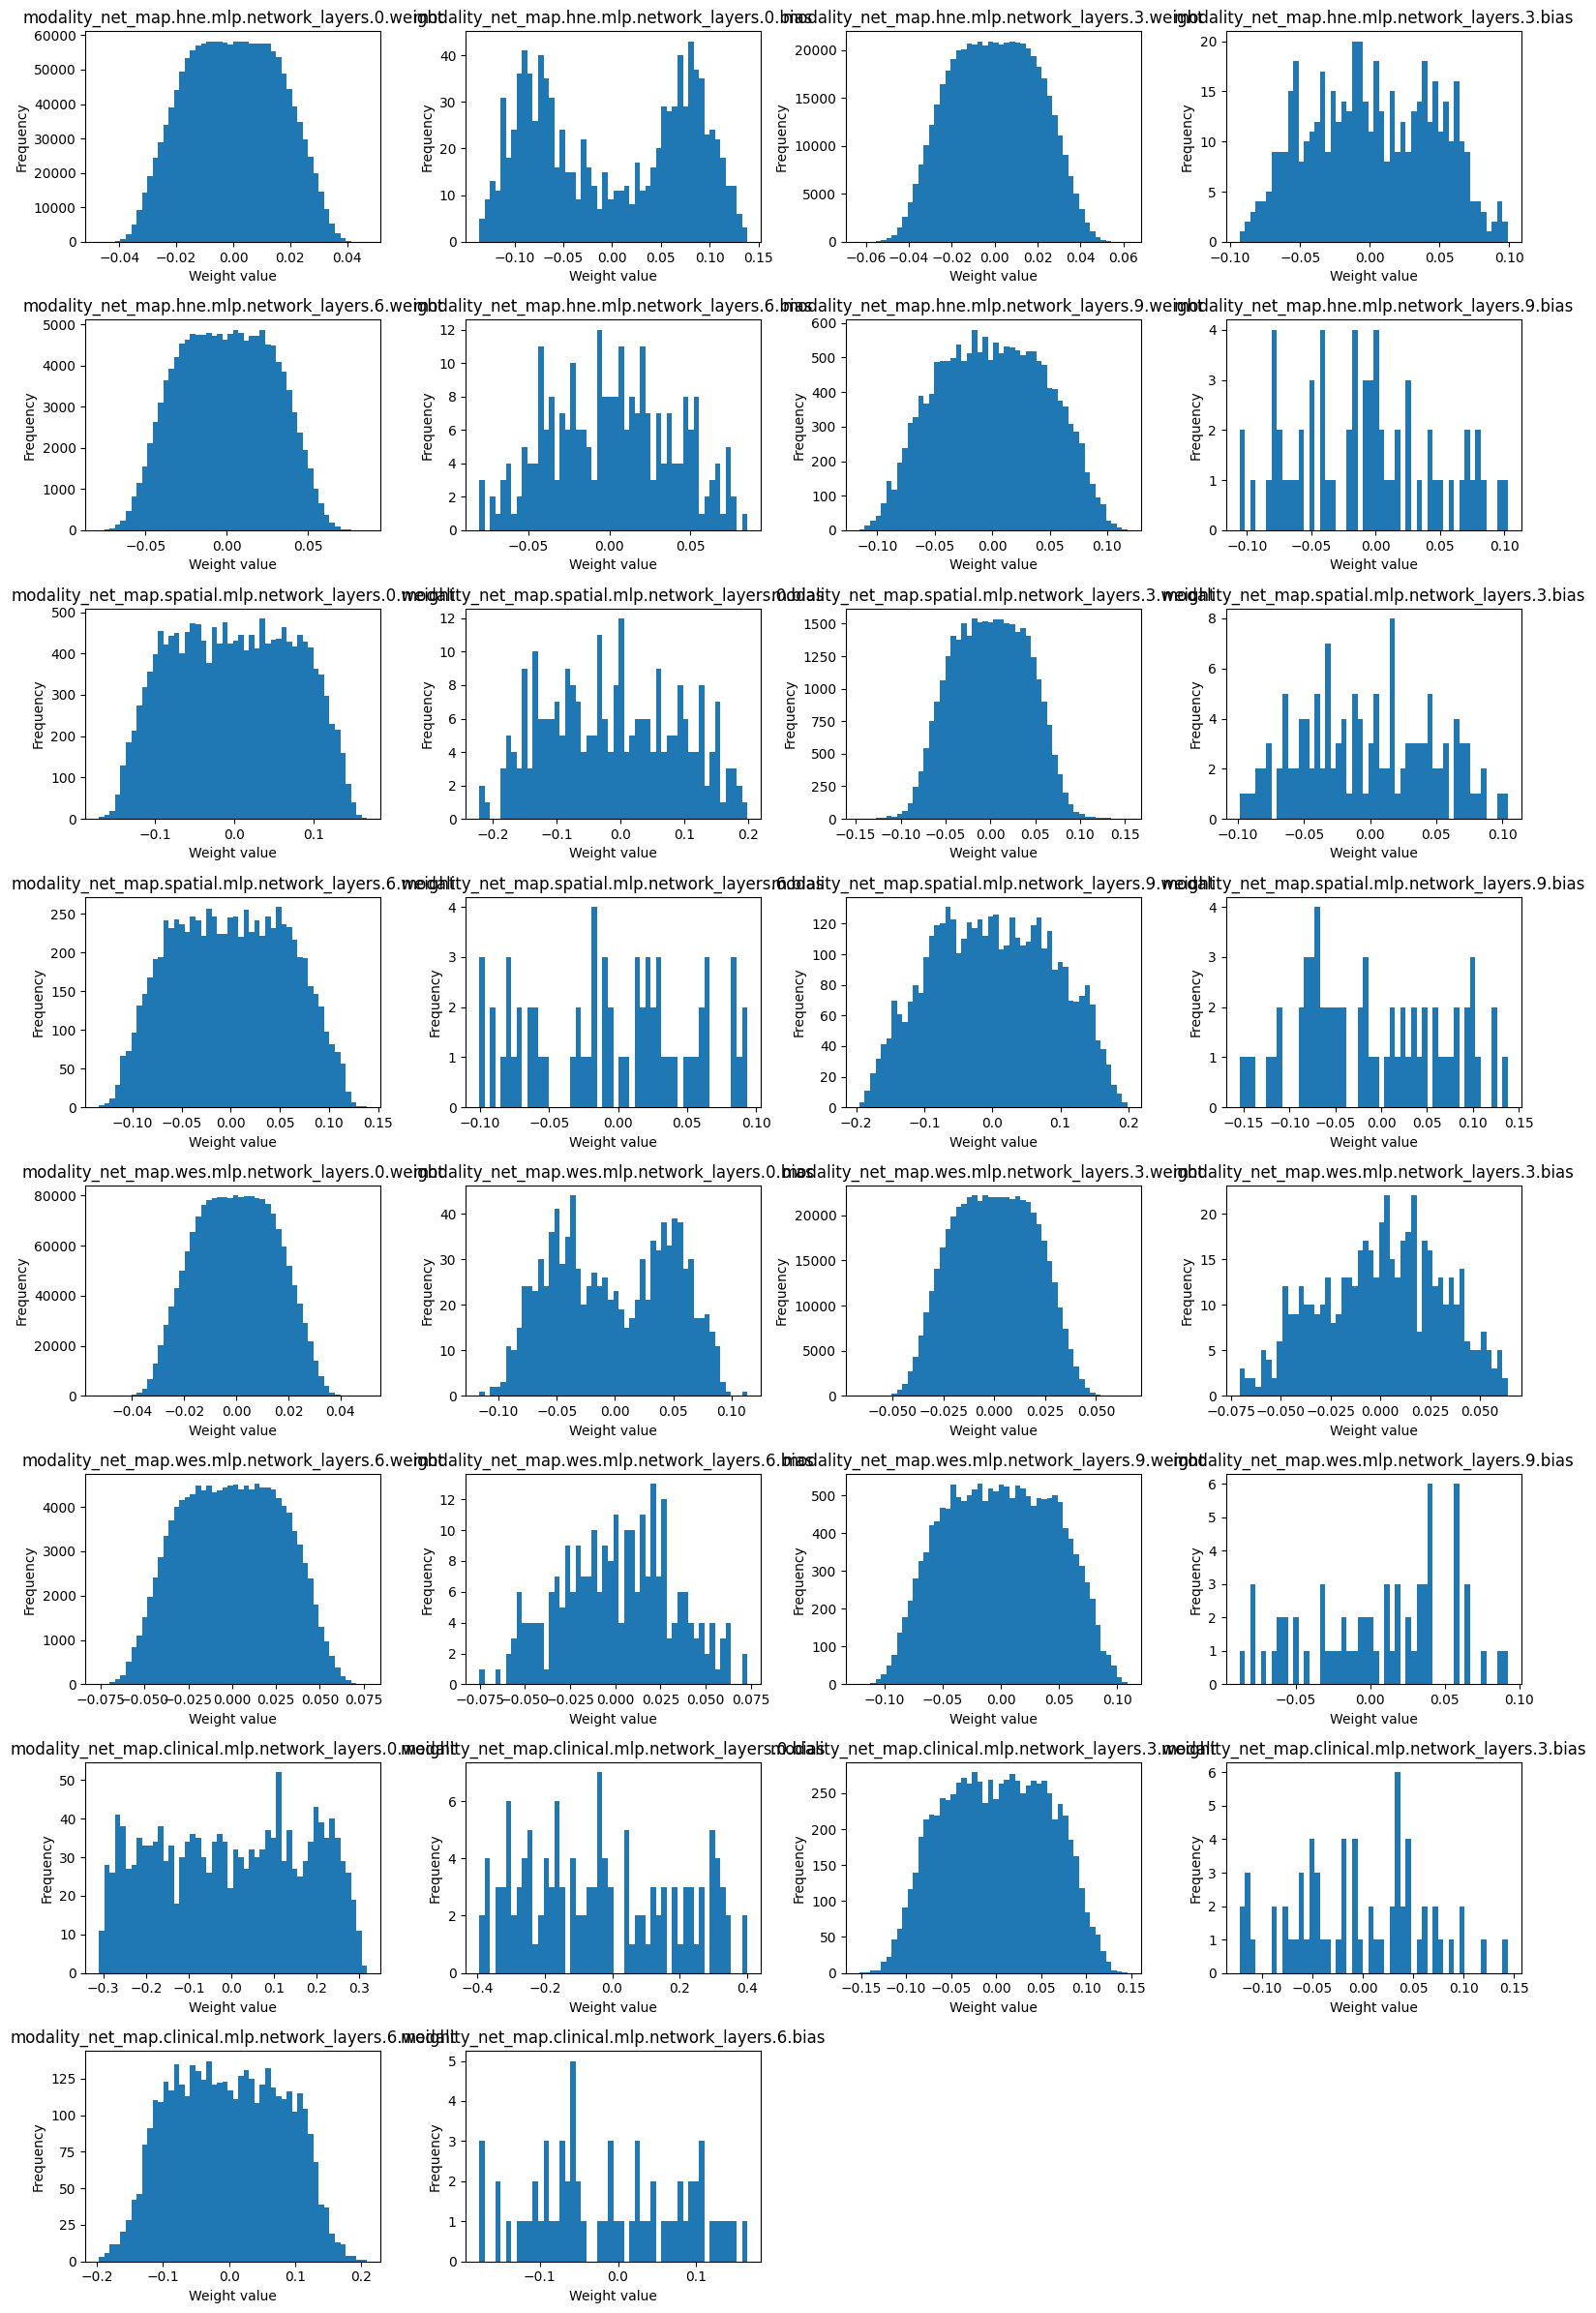

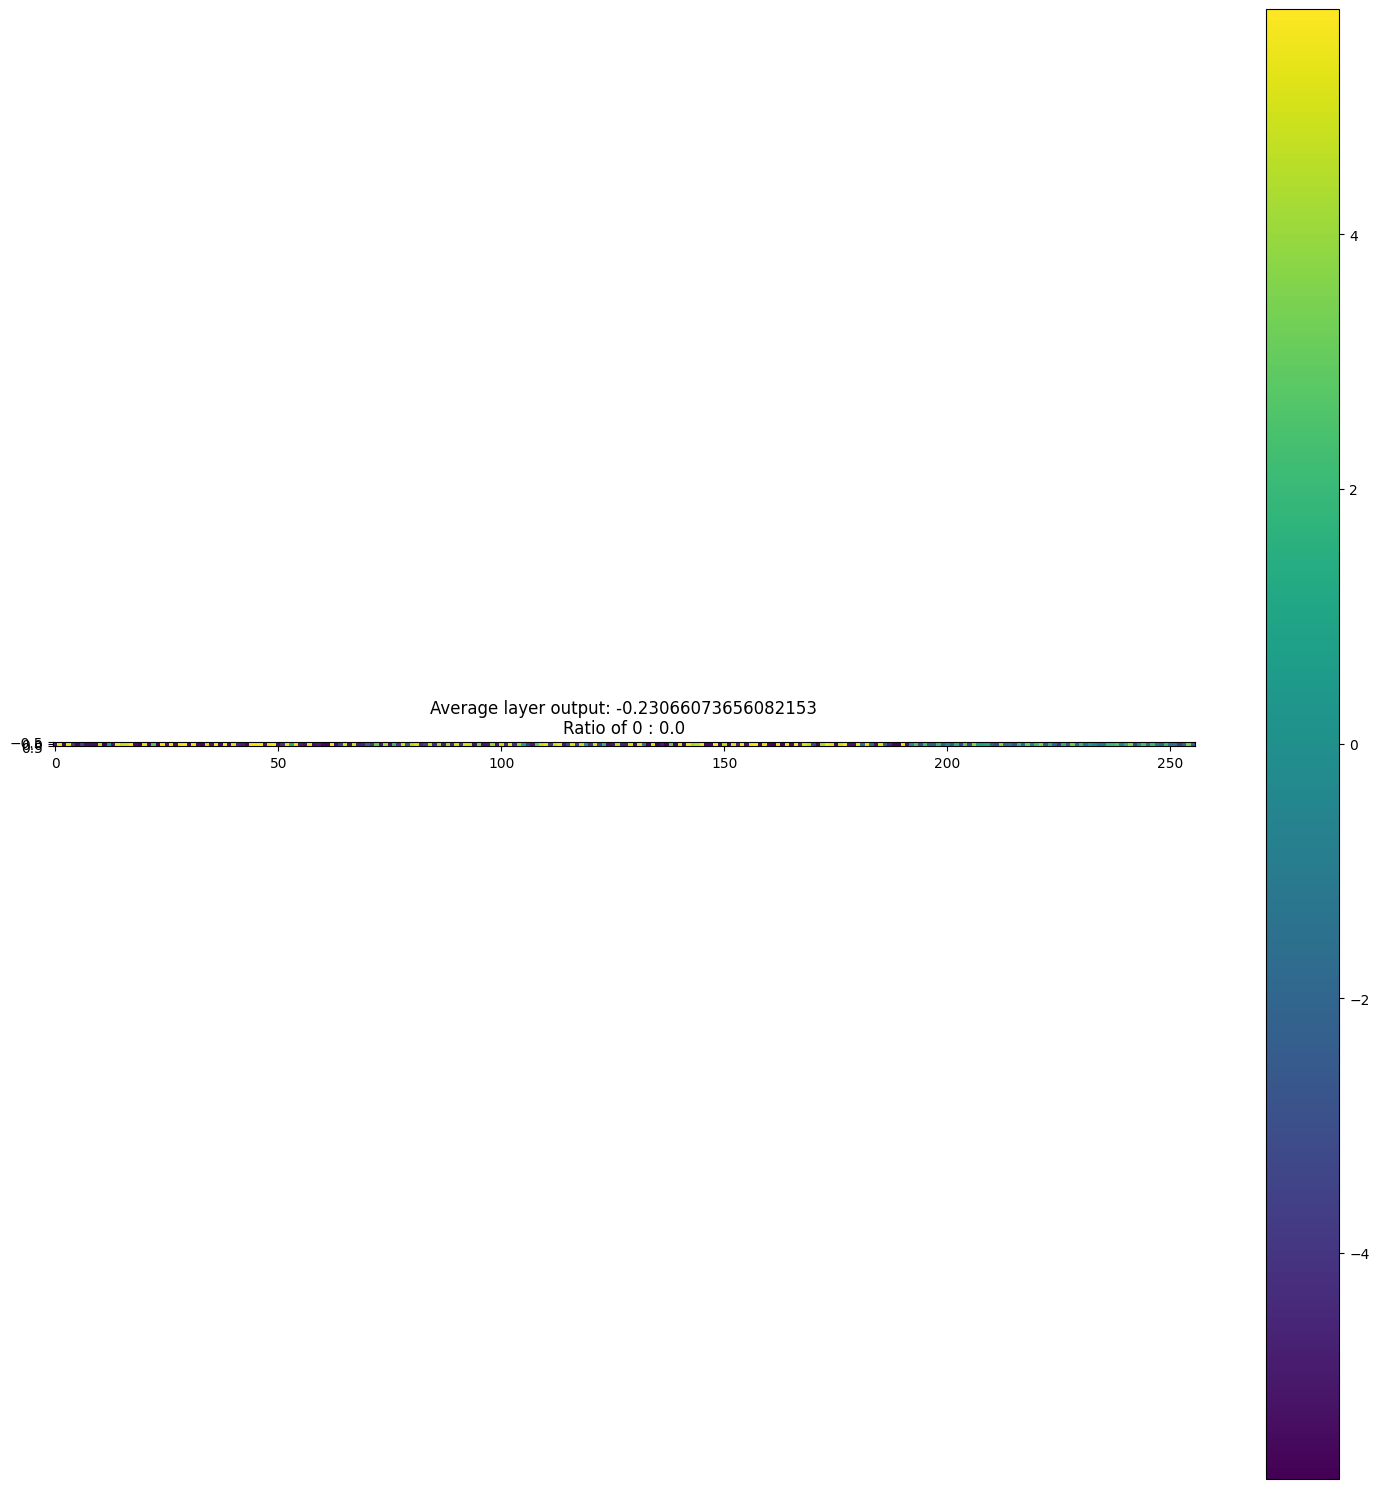

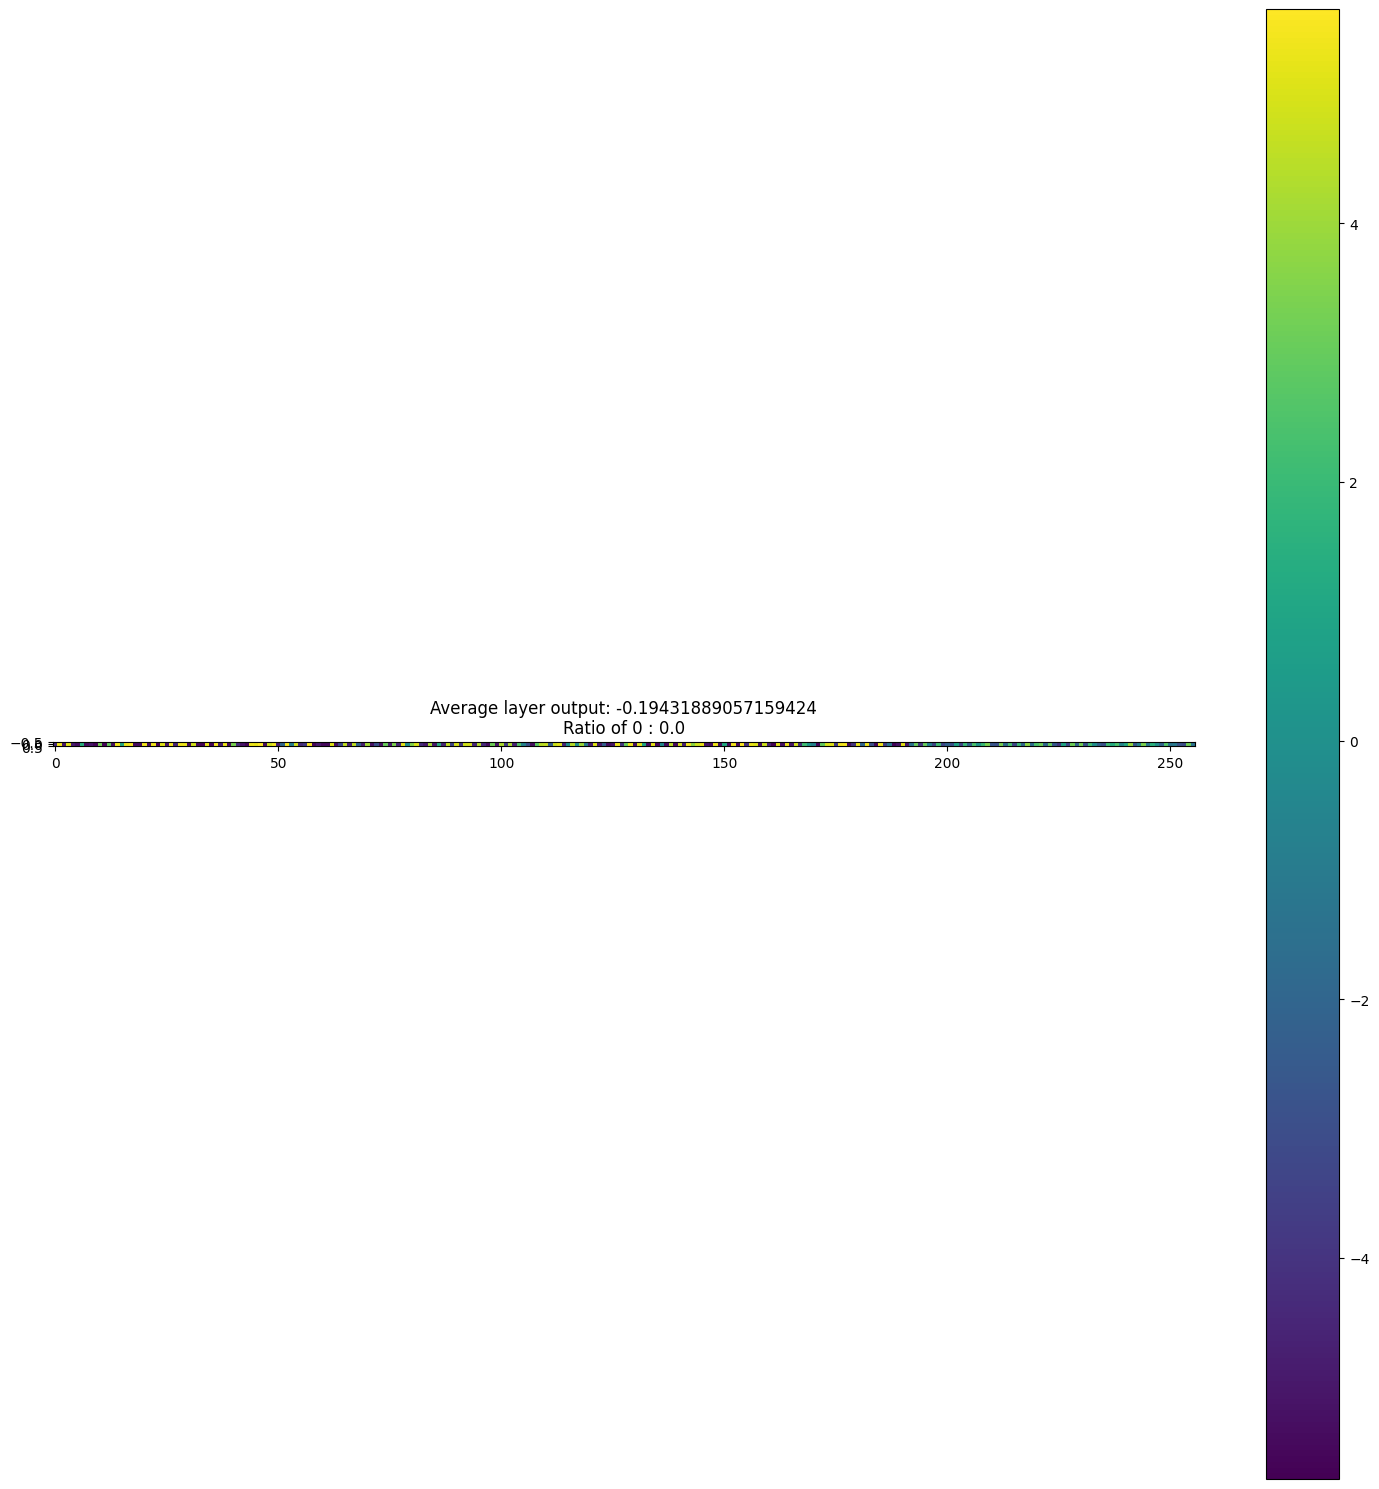

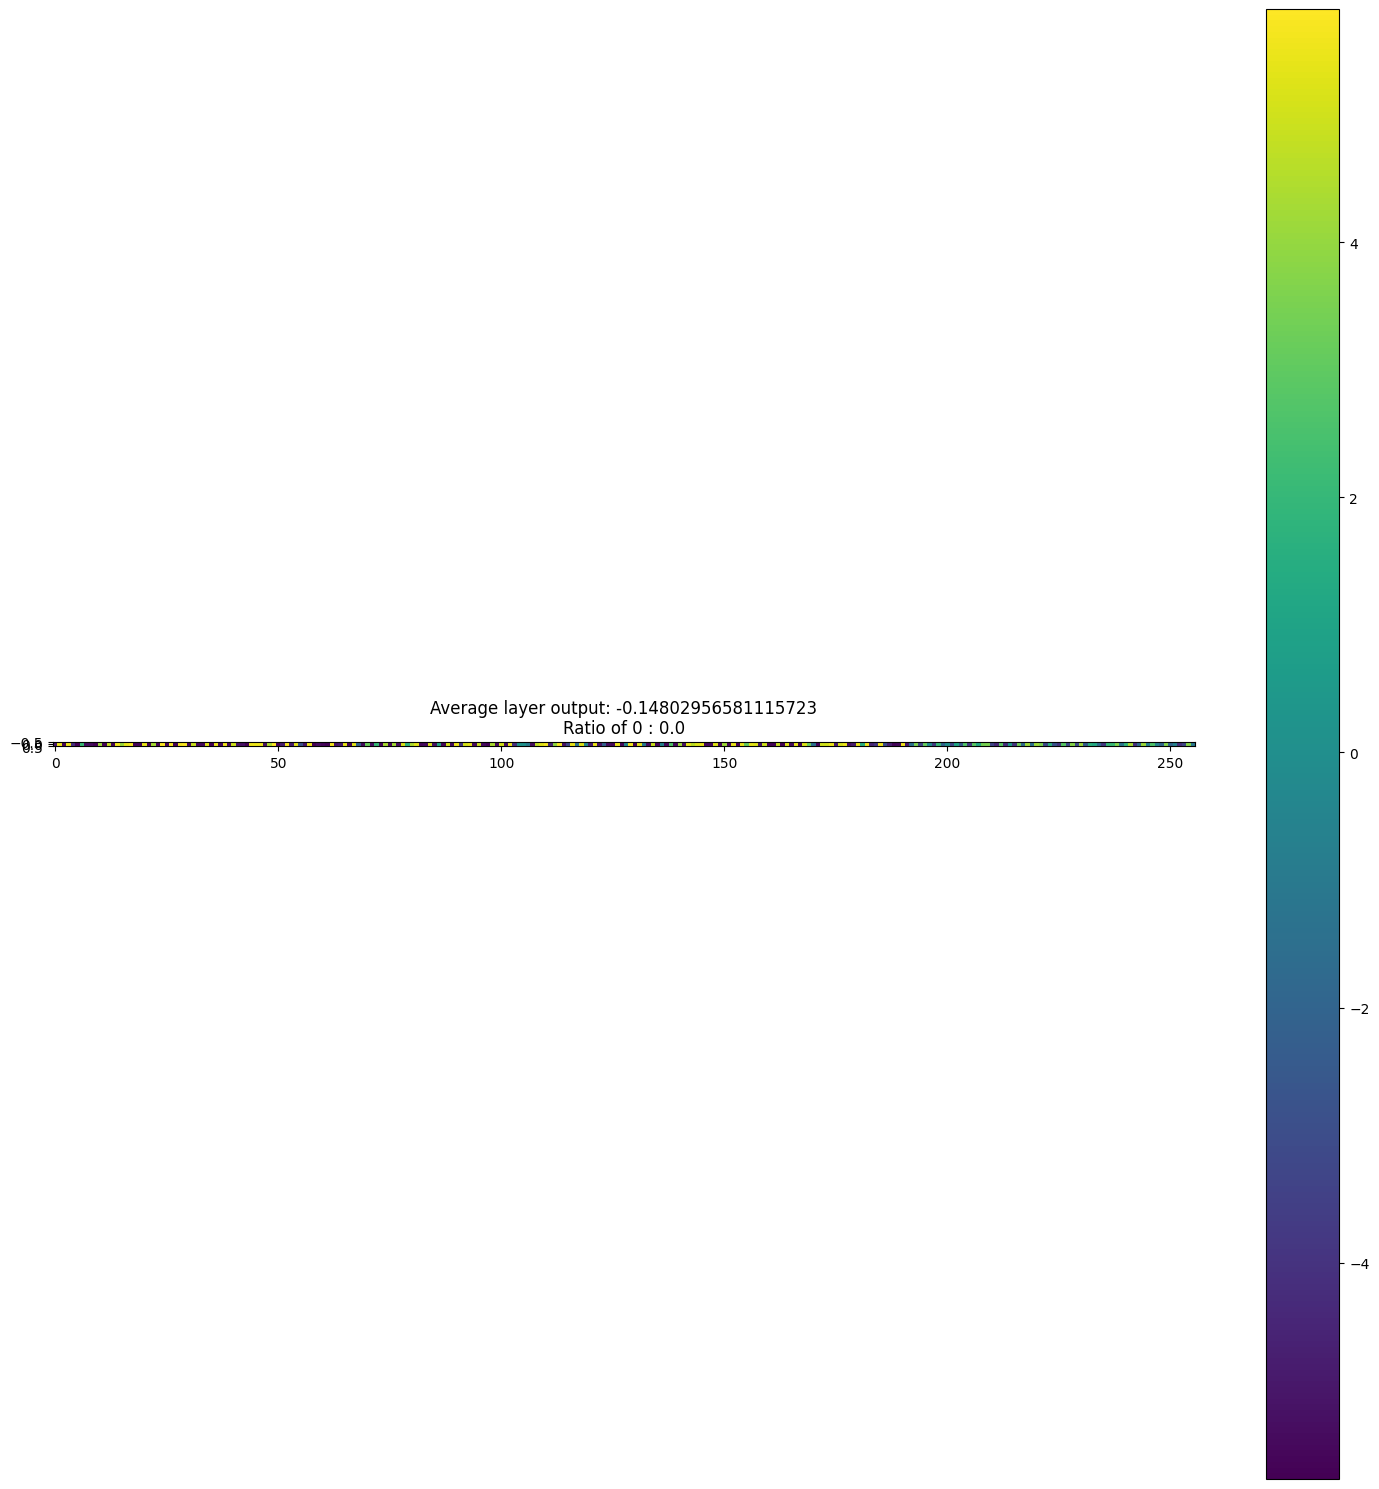

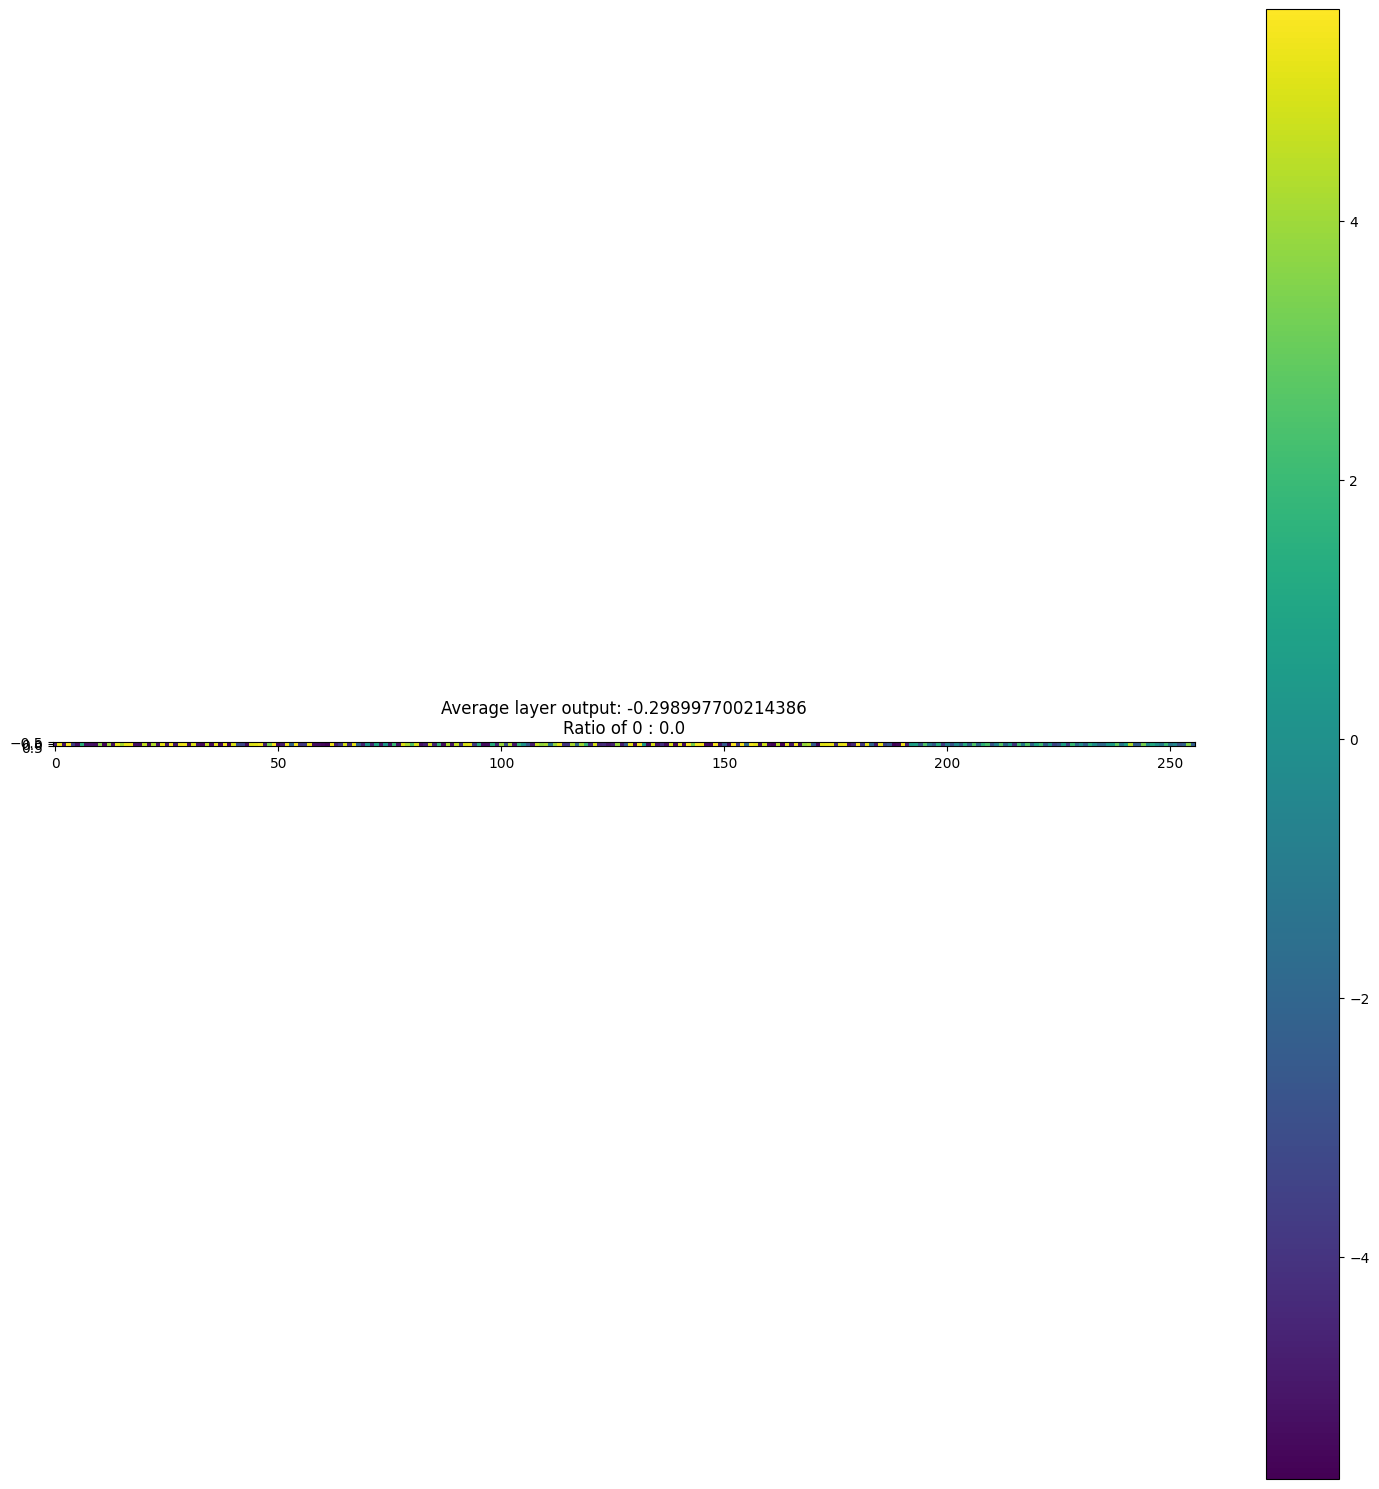

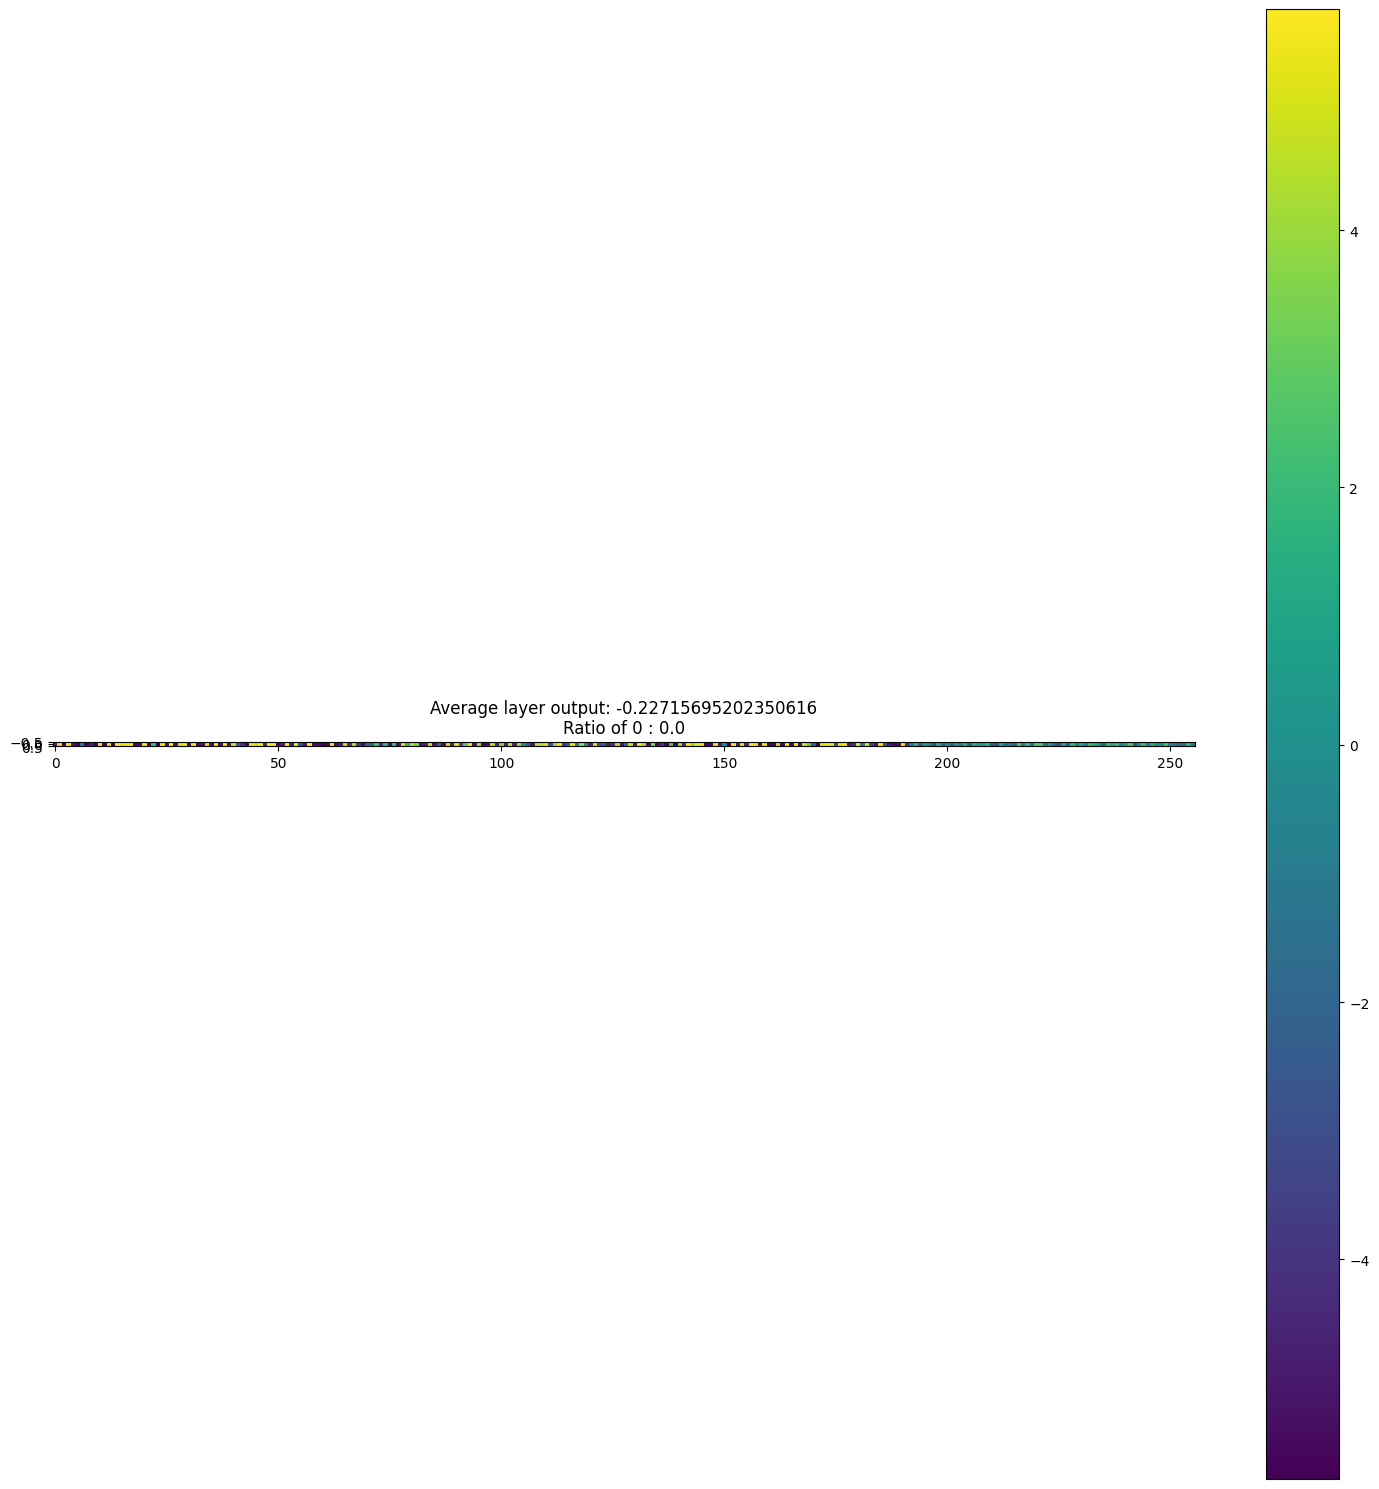

/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/sagemaker-user/.conda/envs/gbmhackathon/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


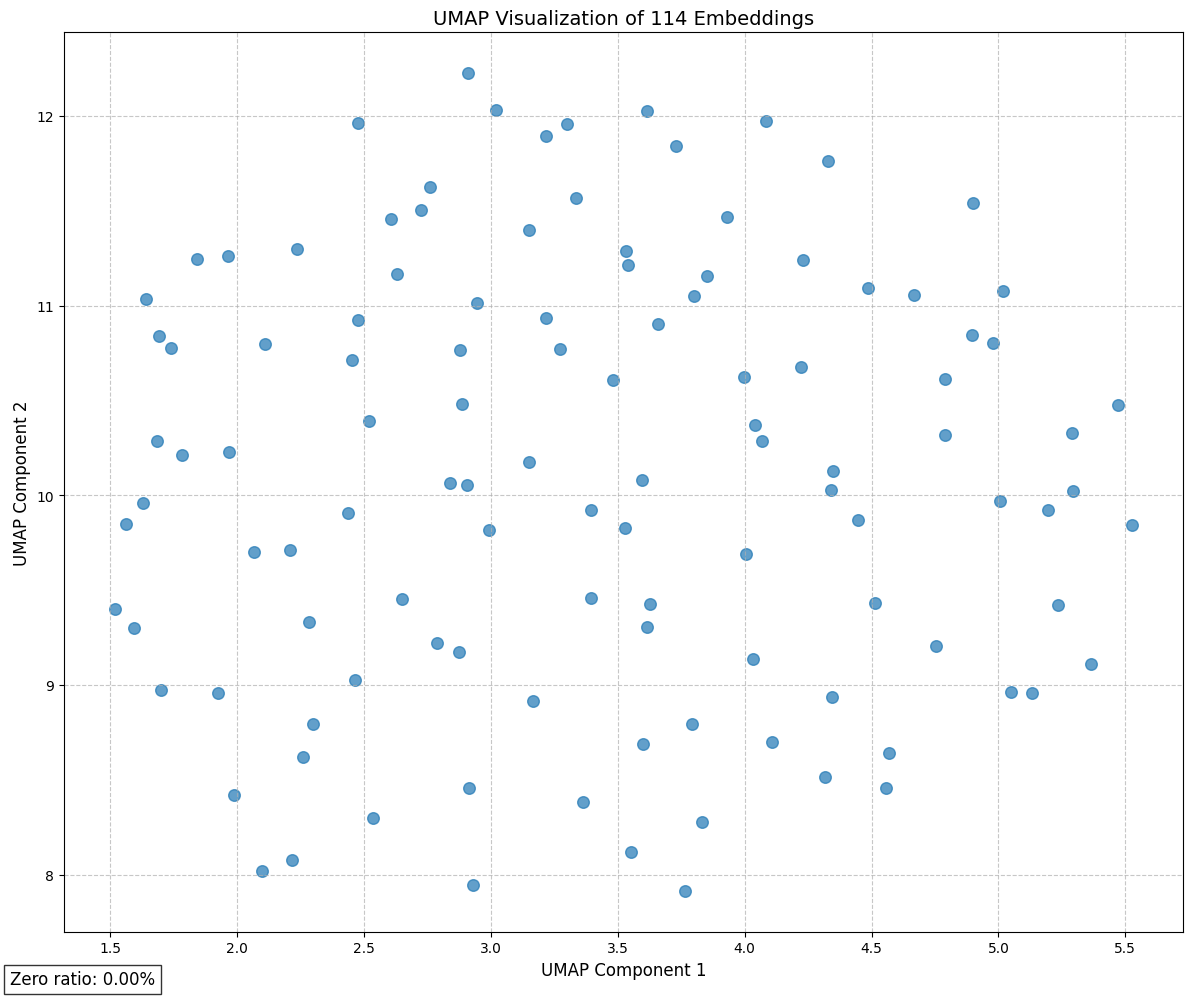


RUN 1:
EPOCH 0 LOSS: 0.4965
EPOCH 1 LOSS: 0.6816
EPOCH 2 LOSS: -0.0324
EPOCH 3 LOSS: -0.1516
EPOCH 4 LOSS: -0.5431
EPOCH 5 LOSS: -1.2012
EPOCH 6 LOSS: -1.2713
EPOCH 7 LOSS: 0.0642
EPOCH 8 LOSS: -0.0356
EPOCH 9 LOSS: -0.7989
EPOCH 10 LOSS: -0.9055
EPOCH 11 LOSS: -1.0916
EPOCH 12 LOSS: -0.9608
EPOCH 13 LOSS: -1.6429
EPOCH 14 LOSS: -1.0400
EPOCH 15 LOSS: -2.1475
EPOCH 16 LOSS: -0.9845
EPOCH 17 LOSS: -1.4375
EPOCH 18 LOSS: -1.7328
EPOCH 19 LOSS: -2.7061
EPOCH 20 LOSS: -2.4324
EPOCH 21 LOSS: -2.7142
EPOCH 22 LOSS: -2.3250
EPOCH 23 LOSS: -3.2938
EPOCH 24 LOSS: -3.0451
EPOCH 25 LOSS: -2.8785
EPOCH 26 LOSS: -3.4245
EPOCH 27 LOSS: -3.3678
EPOCH 28 LOSS: -3.4760
EPOCH 29 LOSS: -3.5280
EPOCH 30 LOSS: -3.6416
EPOCH 31 LOSS: -3.5749
EPOCH 32 LOSS: -3.8985
EPOCH 33 LOSS: -3.8371



KeyboardInterrupt



In [18]:
run_outputs = log_and_plot_runs(10, run_debug, 100, 0.05, "nt-xent", 
                  alpha=0.1, # Coefficient de la régularisation inverse -> Favorise peu de 0 dans les emb de sorties
                  beta=0.05, # Coefficient de la régularisation sur les outputs qui depasse BOUND, -> On favorise des inputs entre -BOUND et BOUND
                  bound=-10, # Defini l'intervalle -BOUND, BOUND pour la loss, on utilisera tout le temps ça je pense
                  show_w=True, show_out_all=True, show_emb=True)

In [ ]:
BUCKET_MOSAIC = "ABSTRA_DATASET_03bb30aa_16ed_4b89_913e_fe009db2aabd"
BUCKET_PROJECT = "ABSTRA_PROJECT_STORAGE_BUCKET"

def fetch_path(env_var_name):
    return os.path.expandvars(f"${env_var_name}")

S3_PATH_CLINICAL_EMB = fetch_path(BUCKET_PROJECT) + "embedding_V1/2025-03-30_14-23_clinical_emb_V1.pkl"
S3_PATH_PROJECT = fetch_path(BUCKET_PROJECT)
clinical_dict = load_s3(S3_PATH_CLINICAL_EMB)

In [ ]:
id2row = clinical_dict['dataset']['id2row']
X = clinical_dict['dataset']['X']
Y = clinical_dict['dataset']['Y']
features = clinical_dict['dataset']['features']
targets = clinical_dict['dataset']['targets']
per_mod_contributions = clinical_dict['dataset']['mca_contributions']

In [ ]:
targets = targets[:2] + ["largest_diameter", targets[-1]]
Y_df = pd.DataFrame(Y.numpy(), columns=targets, index=list(id2row.keys()))

In [ ]:
def analyze_run_outputs(run_results):
    umap = UMAP(random_state=42)  # Set random_state for reproducibility
    
    for run in range(len(run_results)):
        # Convert tensor to numpy array
        if torch.is_tensor(run_results[run]):
            MME_df = pd.DataFrame(run_results[run].detach().cpu().numpy(), 
                                  index=list(dataset.ind2patient.values()))
        else:
            MME_df = pd.DataFrame(run_results[run], 
                                  index=list(dataset.ind2patient.values()))
        
        # Apply UMAP dimensionality reduction
        umap_X = pd.DataFrame(umap.fit_transform(MME_df), 
                            columns=['UMAP1', 'UMAP2'], 
                            index=MME_df.index)
        
        # Combine with target variables
        umap_df = umap_X.join(Y_df)

        # Create figure with the correct number of subplots based on the number of targets
        num_targets = len(targets)
        n_rows = (num_targets + 1) // 2  # Calculate rows needed (ceiling division)
        n_cols = min(2, num_targets)     # Max 2 columns
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
        
        # Make axes iterable even when there's only one subplot
        if num_targets == 1:
            axes = np.array([axes])
        
        # Flatten axes array for easy indexing
        if num_targets > 1:
            axes = axes.flatten()
        
        # Create one subplot for each target
        for i, target in enumerate(targets):
            ax = axes[i] if num_targets > 1 else axes
            
            # Check if target column exists and is not all NaN
            if target in umap_df.columns and not umap_df[target].isna().all():
                # Make sure the target column is properly encoded for coloring
                if umap_df[target].dtype == 'object' or umap_df[target].dtype.name == 'category':
                    # For categorical data, make sure there's a proper mapping
                    scatter = sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue=target, ax=ax)
                else:
                    # For numerical data, use a colormap
                    scatter = sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue=target, 
                                             palette='inferno', ax=ax)
                
                # Only add legend if there are actually labeled points
                handles, labels = ax.get_legend_handles_labels()
                if len(handles) > 0:
                    ax.legend(handles=handles, labels=labels, bbox_to_anchor=(1.05, 1), 
                             loc='upper left', title=target)
                else:
                    print(f"Warning: No labels found for target '{target}'. Check if column exists or has valid values.")
            else:
                # If target doesn't exist or is all NaN, just plot the points without color encoding
                ax.scatter(umap_df['UMAP1'], umap_df['UMAP2'], alpha=0.5, color='gray')
                print(f"Warning: Target '{target}' not found in data or contains only NaN values.")
            
            # Set title
            ax.set_title(f"RUN: {run}, TARGET: {target}")
        
        # Remove any empty subplots
        if num_targets < n_rows * n_cols:
            for i in range(num_targets, n_rows * n_cols):
                if i < len(axes):  # Make sure we don't try to access non-existent axes
                    fig.delaxes(axes[i])
        
        # Adjust layout to prevent overlap
        plt.tight_layout()
        plt.show()

In [ ]:
analyze_run_outputs(run_outputs)